## Ejercicio Práctico 1: Análisis de estrategias de opciones con datos reales

**Hecho por Dayanni Godoy Rosales y nadieee más >:(**

## Paso 1

In [13]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from datetime import datetime

## Paso 2
Descargar el spot de AAPL y seleccionar automáticamente una expiración LEAPS (>365 días).

In [14]:
ticker = yf.Ticker("AAPL")

# Spot actual
spot = ticker.history(period="1d")["Close"].iloc[-1]

print(f"Spot actual AAPL: {spot:.2f}")

# Fechas de expiración
expirations = ticker.options

today = datetime.today()

# Selección automática LEAPS (>365 días)
leaps_exp = None

for exp in expirations:
    
    exp_date = datetime.strptime(exp, "%Y-%m-%d")
    days_to_exp = (exp_date - today).days

    if days_to_exp > 365:
        leaps_exp = exp
        break

print(f"Expiración seleccionada: {leaps_exp}")

# Descargar cadena de opciones
option_chain = ticker.option_chain(leaps_exp)

calls = option_chain.calls
puts = option_chain.puts

Spot actual AAPL: 294.80
Expiración seleccionada: 2027-06-17


## Paso 3
Construir la estrategia Bull Call Spread y graficar el payoff.

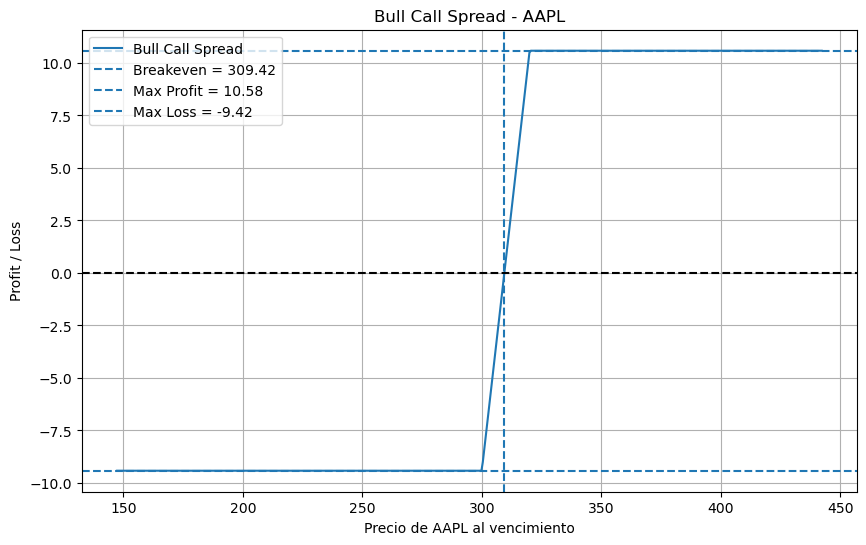

Long Call Strike : 300.0
Short Call Strike: 320.0


In [15]:
# Selección dinámica de strikes
K_long = round(spot * 1.00)   # Long Call ATM
K_short = round(spot * 1.10)  # Short Call OTM

# Buscar contratos más cercanos
long_call = calls.iloc[
    (calls["strike"] - K_long).abs().argsort()[:1]
]

short_call = calls.iloc[
    (calls["strike"] - K_short).abs().argsort()[:1]
]

# Extraer strikes reales
K_long = long_call["strike"].values[0]
K_short = short_call["strike"].values[0]

# Primas
premium_long = long_call["lastPrice"].values[0]
premium_short = short_call["lastPrice"].values[0]

# Costo neto
net_debit = premium_long - premium_short

# Vector de precios
S = np.linspace(spot * 0.5, spot * 1.5, 500)

# Payoff Long Call
long_call_payoff = (
    np.maximum(S - K_long, 0)
    - premium_long
)

# Payoff Short Call
short_call_payoff = (
    -np.maximum(S - K_short, 0)
    + premium_short
)

# Payoff total
bull_call_spread = (
    long_call_payoff
    + short_call_payoff
)

# Métricas
max_profit = (K_short - K_long) - net_debit
max_loss = net_debit
breakeven = K_long + net_debit

# Gráfico
plt.figure(figsize=(10,6))

plt.plot(S, bull_call_spread, label="Bull Call Spread")

plt.axhline(0, color='black', linestyle='--')

plt.axvline(
    breakeven,
    linestyle='--',
    label=f'Breakeven = {breakeven:.2f}'
)

plt.axhline(
    max_profit,
    linestyle='--',
    label=f'Max Profit = {max_profit:.2f}'
)

plt.axhline(
    -max_loss,
    linestyle='--',
    label=f'Max Loss = {-max_loss:.2f}'
)

plt.title("Bull Call Spread - AAPL")

plt.xlabel("Precio de AAPL al vencimiento")
plt.ylabel("Profit / Loss")

plt.legend()
plt.grid(True)

plt.show()

print(f"Long Call Strike : {K_long}")
print(f"Short Call Strike: {K_short}")

## Paso 4
Construir Protective Put y graficar payoff del portafolio.

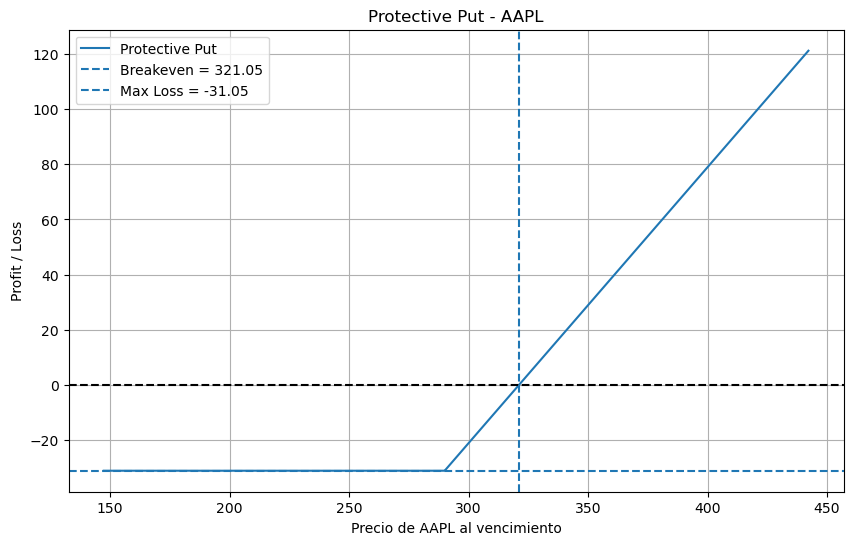

Strike Put: 290.0


In [16]:
# Strike ATM dinámico
K_put = round(spot)

# Buscar put ATM
put_contract = puts.iloc[(puts["strike"] - K_put).abs().argsort()[:1]]

K_put = put_contract["strike"].values[0]
put_premium = put_contract["lastPrice"].values[0]

# Payoff stock
stock_payoff = S - spot

# Payoff long put
put_payoff = np.maximum(K_put - S, 0) - put_premium

# Protective put
protective_put = stock_payoff + put_payoff

# Métricas
breakeven_pp = spot + put_premium
max_loss_pp = (spot - K_put) + put_premium

# Gráfico
plt.figure(figsize=(10,6))

plt.plot(S, protective_put, label="Protective Put")
plt.axhline(0, color='black', linestyle='--')

plt.axvline(breakeven_pp, linestyle='--', label=f'Breakeven = {breakeven_pp:.2f}')
plt.axhline(-max_loss_pp, linestyle='--', label=f'Max Loss = {-max_loss_pp:.2f}')

plt.title("Protective Put - AAPL")
plt.xlabel("Precio de AAPL al vencimiento")
plt.ylabel("Profit / Loss")

plt.legend()
plt.grid(True)

plt.show()

print(f"Strike Put: {K_put}")

## Paso 5
Crear función Black-Scholes y cálculo de Griegas.

In [17]:
def black_scholes_greeks(
    S,
    K,
    T,
    r,
    sigma,
    option_type='call'
):

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    # Precio y Delta
    if option_type == 'call':

        price = (
            S * norm.cdf(d1)
            - K * np.exp(-r * T) * norm.cdf(d2)
        )

        delta = norm.cdf(d1)

    else:

        price = (
            K * np.exp(-r * T) * norm.cdf(-d2)
            - S * norm.cdf(-d1)
        )

        delta = norm.cdf(d1) - 1

    # Gamma
    gamma = (
        norm.pdf(d1)
        / (S * sigma * np.sqrt(T))
    )

    # Theta
    theta = (
        -(S * norm.pdf(d1) * sigma)
        / (2 * np.sqrt(T))
        - r * K * np.exp(-r * T)
        * norm.cdf(
            d2 if option_type == 'call'
            else -d2
        )
    ) / 365

    # Vega
    vega = (
        S * norm.pdf(d1)
        * np.sqrt(T)
    ) / 100

    return {
        "price": price,
        "delta": delta,
        "gamma": gamma,
        "theta": theta,
        "vega": vega
    }

## Paso 6
Calcular Griegas individuales y Griegas netas de ambos portafolios.

In [18]:
# Tasa libre de riesgo
r = 0.05

# Aproximación simple volatilidad anualizada
returns = (
    ticker.history(period="1y")["Close"]
    .pct_change()
    .dropna()
)

sigma = returns.std() * np.sqrt(252)

print(f"Volatilidad anualizada: {sigma:.4f}")

# Tiempo a vencimiento
expiration_date = datetime.strptime(
    leaps_exp,
    "%Y-%m-%d"
)

T = (
    (expiration_date - today).days
    / 365
)

# Greeks Long Call
greeks_long_call = black_scholes_greeks(
    spot,
    K_long,
    T,
    r,
    sigma,
    'call'
)

# Greeks Short Call
greeks_short_call = black_scholes_greeks(
    spot,
    K_short,
    T,
    r,
    sigma,
    'call'
)

# Greeks Long Put
greeks_put = black_scholes_greeks(
    spot,
    K_put,
    T,
    r,
    sigma,
    'put'
)

# Net Greeks Bull Call Spread
bull_delta = (
    greeks_long_call["delta"]
    - greeks_short_call["delta"]
)

bull_gamma = (
    greeks_long_call["gamma"]
    - greeks_short_call["gamma"]
)

bull_theta = (
    greeks_long_call["theta"]
    - greeks_short_call["theta"]
)

bull_vega = (
    greeks_long_call["vega"]
    - greeks_short_call["vega"]
)

# Net Greeks Protective Put
pp_delta = 1 + greeks_put["delta"]

pp_gamma = greeks_put["gamma"]

pp_theta = greeks_put["theta"]

pp_vega = greeks_put["vega"]

# Resultados individuales
print("\n= LONG CALL =")
print(greeks_long_call)

print("\n= SHORT CALL =")
print(greeks_short_call)

print("\n= LONG PUT =")
print(greeks_put)

# Resultados netos
print("\n = NET GREEKS: BULL CALL SPREAD =")

print({
    "Delta": bull_delta,
    "Gamma": bull_gamma,
    "Theta": bull_theta,
    "Vega": bull_vega
})

print("\n = NET GREEKS: PROTECTIVE PUT=")

print({
    "Delta": pp_delta,
    "Gamma": pp_gamma,
    "Theta": pp_theta,
    "Vega": pp_vega
})

Volatilidad anualizada: 0.2253

= LONG CALL =
{'price': 32.89876666057674, 'delta': 0.6087724613809156, 'gamma': 0.005524001814410969, 'theta': -0.05344835491919054, 'vega': 1.185127748656573}

= SHORT CALL =
{'price': 24.16879882641848, 'delta': 0.50097307115905, 'gamma': 0.005738632905873185, 'theta': -0.05158750969055959, 'vega': 1.2311750293712054}

= LONG PUT =
{'price': 17.7901992756903, 'delta': -0.3372851230791436, 'gamma': 0.005254436296445105, 'theta': -0.047799971494694546, 'vega': 1.12729475255058}

 = NET GREEKS: BULL CALL SPREAD =
{'Delta': 0.10779939022186558, 'Gamma': -0.00021463109146221612, 'Theta': -0.0018608452286309474, 'Vega': -0.04604728071463238}

 = NET GREEKS: PROTECTIVE PUT=
{'Delta': 0.6627148769208564, 'Gamma': 0.005254436296445105, 'Theta': -0.047799971494694546, 'Vega': 1.12729475255058}


## Interpretación


**1. Bull Call Spread **
* **Condición de mercado:** Es una estrategia alcista moderada. Como el precio actual (aprox. 294.80) está muy cerca de tu primer strike (300), tu expectativa es que la acción suba, idealmente superando los 320 antes del vencimiento en 2027, para que alcances tu ganancia máxima.
* **Análisis de Griegas Netas:**
    * **Delta (0.107):** Es positiva, lo que confirma que tu portafolio se beneficia y gana valor si el precio de la acción sube.
    * **Theta (-0.0018):** Es ligeramente negativa. Al ser una estrategia por la que pagaste para entrar (la Call que compraste es más cara que la que vendiste), el simple paso del tiempo juega un poco en tu contra.
    * **Vega (-0.046):** Es negativa. Te conviene que la volatilidad del mercado disminuya, ya que la opción que vendiste (strike 320) es ligeramente más sensible a la volatilidad que la que compraste; si la volatilidad cae, esa opción se abarata más rápido a tu favor.

**2. Protective Put**
* **Condición de mercado:** Es una estrategia alcista con protección. Mantienes la acción porque esperas que suba, pero compras la Put para ponerle un piso a tus pérdidas en caso de una caída fuerte del mercado.
* **Análisis de Griegas Netas:**
    * **Delta (0.662):** Es positiva, así que ganas si la acción sube. No es 1 exacto porque la Put comprada resta un poco de esa sensibilidad.
    * **Theta (-0.047):** Es negativa y representa el costo de tu seguro. Cada día que pasa sin que el precio se mueva, el portafolio pierde un poco de valor por la prima pagada.
    * **Vega (1.127):** Es positiva y alta. Si hay pánico en el mercado y la volatilidad sube, el valor de tu Put (el seguro) se incrementará bastante.

## Ejercicio Práctico 2: Valuación de opciones exóticas con Monte Carlo

### Paso 1: Parámetros de mercado
Se utilizan parámetros ficticios razonables para una acción tecnológica líquida.  
La barrera B se fija por encima del spot para modelar una opción Up-and-Out realista.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros de mercado
S = 100          # Spot inicial
K = 105          # Strike
T = 1            # Madurez en años
r = 0.04         # Tasa libre de riesgo
sigma = 0.25     # Volatilidad anual
B = 130          # Barrera Up-and-Out

# Configuración Monte Carlo
n_sim = 50000
N = 252 * T
dt = T / N

**Justificación:**

T = 1: Ps nomás.

S=100 y K=105: Opción ligeramente OTM.

r=0.04: Tasa libre de riesgo estadounidense.

sigma=0.25: Volatilidad histórica típica de una big tech estable.

B=130: Se coloca un 30% por encima del spot para dar margen de movimiento sin que la opción se desactive inmediatamente.

### Paso 2: Simulación Monte Carlo
Se generan trayectorias completas usando Movimiento Browniano Geométrico.  
La simulación se vectoriza completamente con numpy para eficiencia computacional.

In [20]:
# Semilla reproducible
np.random.seed(42)

# Variables aleatorias normales
Z = np.random.normal(0, 1, (n_sim, N))

# Incrementos logarítmicos
drift = (r - 0.5 * sigma**2) * dt
diffusion = sigma * np.sqrt(dt) * Z

# Trayectorias logarítmicas
log_returns = drift + diffusion

# Construcción de trayectorias
log_paths = np.cumsum(log_returns, axis=1)

# Agregar valor inicial
paths = S * np.exp(log_paths)

# Insertar precio inicial en t=0
paths = np.concatenate(
    [np.full((n_sim, 1), S), paths],
    axis=1
)

### Paso 3: Cálculo de payoffs
Cada opción utiliza una lógica distinta de valuación sobre las trayectorias simuladas.  
La opción barrera se invalida si el máximo de la trayectoria alcanza B.

In [21]:
# Precio final
ST = paths[:, -1]

# Promedio aritmético de la trayectoria
avg_price = paths.mean(axis=1)

# Máximo de la trayectoria
max_price = paths.max(axis=1)

# Payoff Call Europea
call_payoff = np.maximum(ST - K, 0)

# Payoff Put Europea
put_payoff = np.maximum(K - ST, 0)

# Payoff Call Asiática
asian_call_payoff = np.maximum(avg_price - K, 0)

# Condición barrera Up-and-Out
barrier_active = max_price < B

# Payoff Call Up-and-Out
up_out_call_payoff = np.where(
    barrier_active,
    np.maximum(ST - K, 0),
    0
)

# Descuento a valor presente
discount_factor = np.exp(-r * T)

call_price = discount_factor * np.mean(call_payoff)
put_price = discount_factor * np.mean(put_payoff)
asian_call_price = discount_factor * np.mean(asian_call_payoff)
up_out_call_price = discount_factor * np.mean(up_out_call_payoff)

### Paso 4: Tabla de precios
Los resultados finales se organizan en un DataFrame para facilitar comparación.  
Cada precio corresponde al valor presente esperado bajo medida neutral al riesgo.

In [22]:
results = pd.DataFrame({
    'Opción': [
        'Call Europea',
        'Put Europea',
        'Call Asiática',
        'Call Up-and-Out'
    ],
    'Precio Monte Carlo': [
        call_price,
        put_price,
        asian_call_price,
        up_out_call_price
    ]
})

print(results)

            Opción  Precio Monte Carlo
0     Call Europea            9.868217
1      Put Europea            9.853429
2    Call Asiática            4.576318
3  Call Up-and-Out            1.462561


### Paso 5: Distribuciones de payoffs
Los histogramas permiten visualizar la dispersión y asimetría de los payoffs.  
Cada opción presenta una estructura de riesgo distinta.

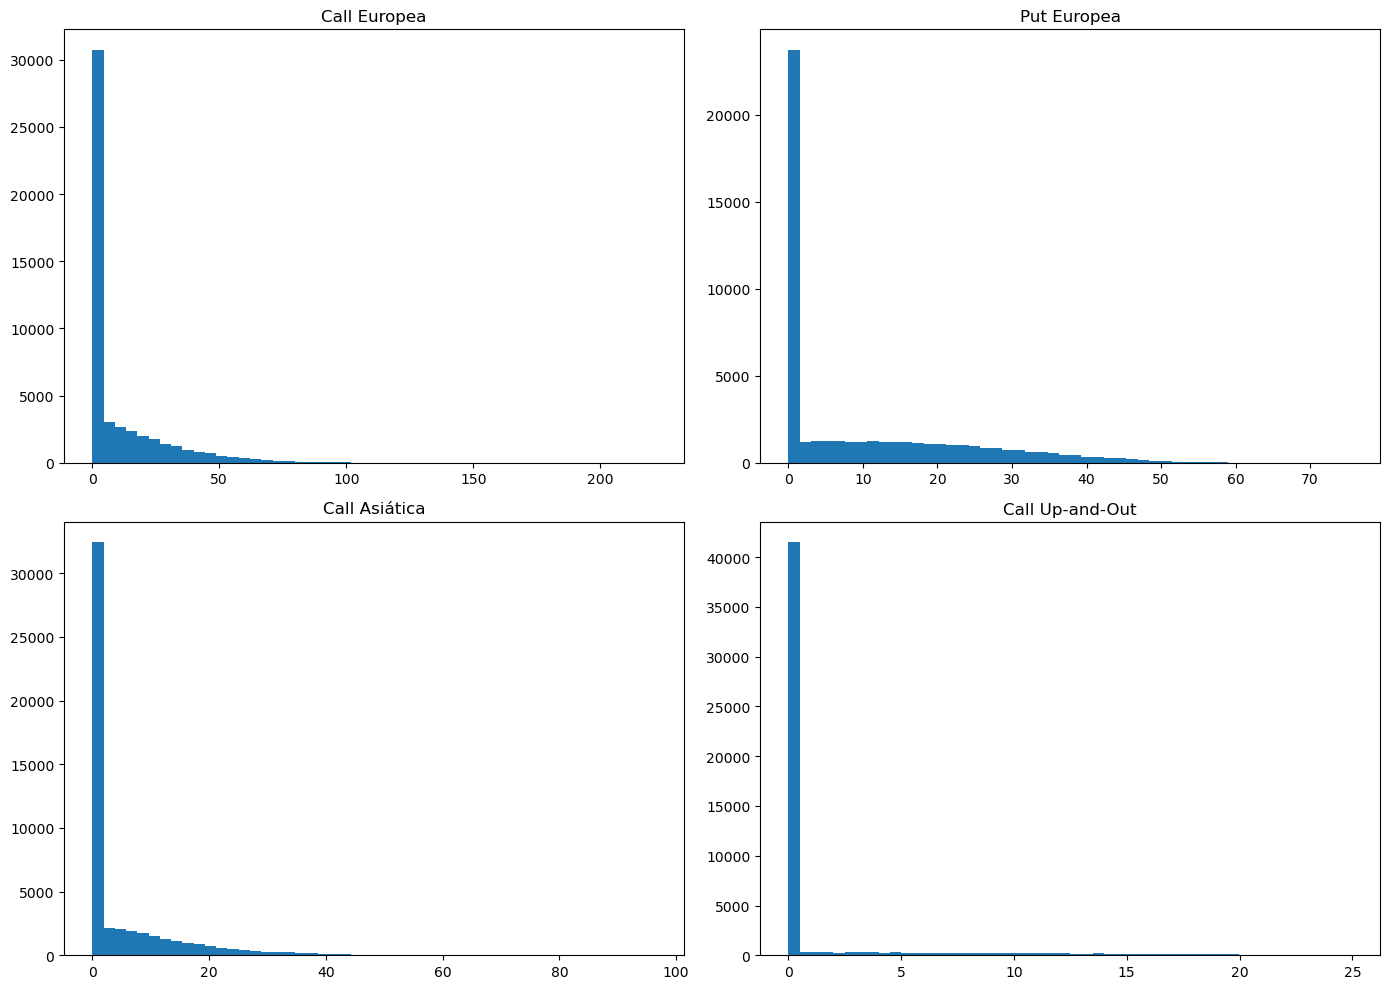

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Call Europea
axes[0, 0].hist(call_payoff, bins=50)
axes[0, 0].set_title('Call Europea')

# Put Europea
axes[0, 1].hist(put_payoff, bins=50)
axes[0, 1].set_title('Put Europea')

# Call Asiática
axes[1, 0].hist(asian_call_payoff, bins=50)
axes[1, 0].set_title('Call Asiática')

# Call Up-and-Out
axes[1, 1].hist(up_out_call_payoff, bins=50)
axes[1, 1].set_title('Call Up-and-Out')

plt.tight_layout()
plt.show()

### Interpretación 

La simulación muestra claramente por qué las opciones exóticas resultan más baratas que las europeas estándar:

* **Call Asiática (4.57 vs 9.86):** Cuesta aproximadamente la mitad. Como su pago final se calcula promediando todos los precios de la trayectoria, los picos altos o movimientos extremos se diluyen. Al suavizar esta volatilidad, el riesgo disminuye y por lo tanto la opción es más barata.

* **Call Up-and-Out (1.46 vs 9.86):** Tiene un descuento muy grande por el riesgo de cancelación. Al tener una barrera en 130, existe una probabilidad real de que el precio de la acción la toque durante el año de vida del contrato. Si la toca, la opción se desactiva y vale cero, lo que reduce drásticamente el precio que el mercado está dispuesto a pagar por ella hoy.